### 4.(a) Train an ANN to classify the MNIST dataset. Report training accuracy and test accuracy

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8722 - loss: 0.4699 - val_accuracy: 0.9564 - val_loss: 0.1553
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9605 - loss: 0.1357 - val_accuracy: 0.9674 - val_loss: 0.1105
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9742 - loss: 0.0868 - val_accuracy: 0.9678 - val_loss: 0.1083
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9799 - loss: 0.0663 - val_accuracy: 0.9710 - val_loss: 0.0961
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9853 - loss: 0.0484 - val_accuracy: 0.9742 - val_loss: 0.0890
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9897 - loss: 0.0353 - val_accuracy: 0.9754 - val_loss: 0.0950
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9732 - val_loss: 0.0936
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9930 - loss: 0.0242 

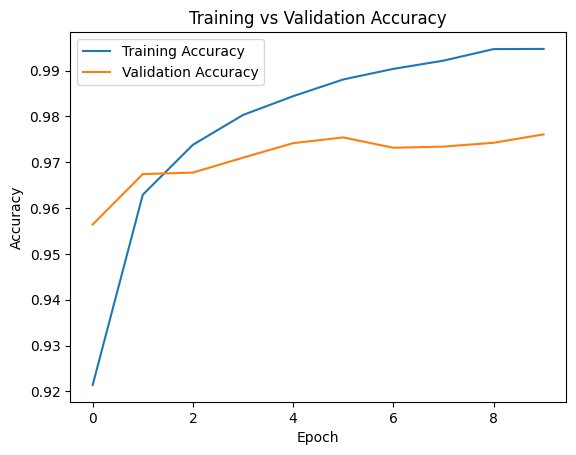

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Define the ANN model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),             # Flatten 28x28 images to 1D
    keras.layers.Dense(128, activation='relu'),             # Hidden layer with 128 neurons
    keras.layers.Dense(10, activation='softmax')            # Output layer (10 classes)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Label: 1
True Label: 1


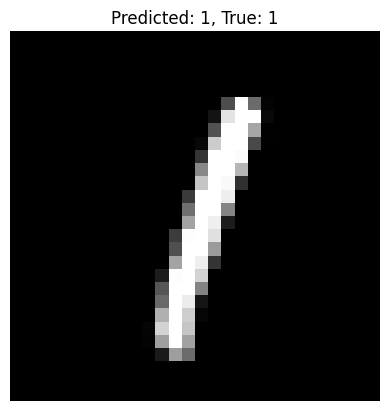

In [4]:
# Predict on a test image
sample_idx = 5
sample_image = X_test[sample_idx]
prediction = model.predict(np.array([sample_image]))
predicted_label = np.argmax(prediction)

print(f"Predicted Label: {predicted_label}")
print(f"True Label: {y_test[sample_idx]}")

# Display the sample image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Predicted: {predicted_label}, True: {y_test[sample_idx]}")
plt.axis('off')
plt.show()

### 4(b) Explain the vanishing gradient problem in RNNs and demonstrate using simple RNN and 	LSTM. 


Training Simple RNN model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4940 - loss: 0.7387 - val_accuracy: 0.4300 - val_loss: 0.7073
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4597 - loss: 0.7046 - val_accuracy: 0.4800 - val_loss: 0.6941
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5050 - loss: 0.6953 - val_accuracy: 0.5300 - val_loss: 0.6912
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5124 - loss: 0.6921 - val_accuracy: 0.4950 - val_loss: 0.6916
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4940 - loss: 0.6910 - val_accuracy: 0.5300 - val_loss: 0.6844
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5421 - loss: 0.6926 - val_accuracy: 0.6050 - val_loss: 0.6801
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5772 - loss: 0.6784 - val_accuracy: 0.6300 - val_loss: 0.6554
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5955 - loss: 0.668

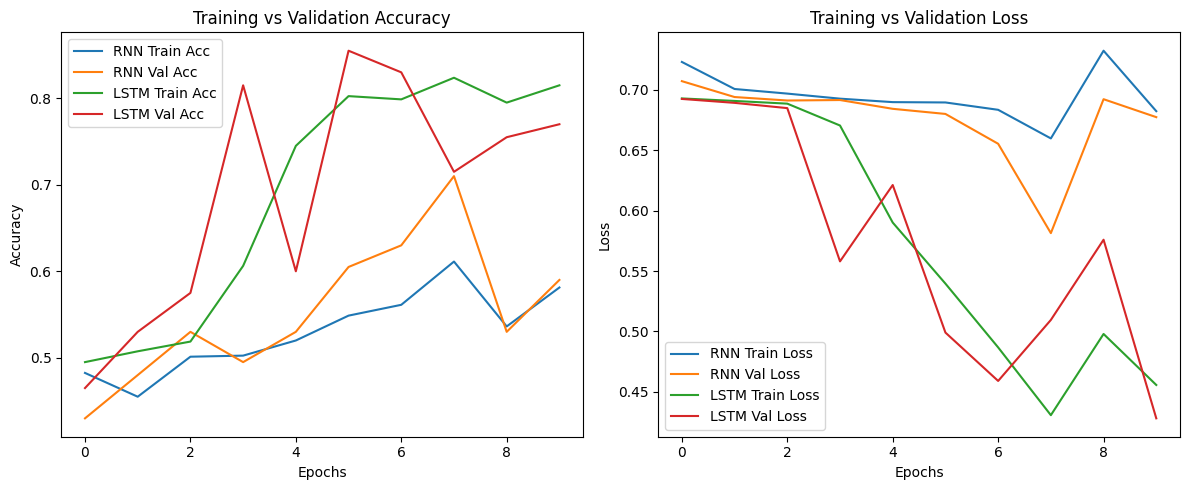


--- Final Evaluation ---
RNN Test Accuracy: 0.5270
LSTM Test Accuracy: 0.7860


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
import matplotlib.pyplot as plt

# 1. Generate synthetic sequential data
# Longer sequences increase the vanishing gradient effect
def generate_sequence_data(seq_len=100):
    X = np.random.rand(1000, seq_len, 1)  # 1000 samples, sequence length, 1 feature
    y = (np.sum(X, axis=1) > (seq_len / 2)).astype(int)  # binary label: sum > threshold
    return X, y

X_train, y_train = generate_sequence_data()
X_test, y_test = generate_sequence_data()

# 2. Define and compile a Simple RNN model
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(X_train.shape[1], 1)),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Define and compile an LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(X_train.shape[1], 1)),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train both models and store history
print("\nTraining Simple RNN model...")
rnn_history = rnn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

print("\nTraining LSTM model...")
lstm_history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# 5. Evaluate both models on test data
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)

# 6. Plot training accuracy and loss for both models
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='RNN Train Acc')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Val Acc')
plt.plot(lstm_history.history['accuracy'], label='LSTM Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 7. Final test results
print("\n--- Final Evaluation ---")
print(f"RNN Test Accuracy: {rnn_test_acc:.4f}")
print(f"LSTM Test Accuracy: {lstm_test_acc:.4f}")
